# Mixed equivalence analysis

## Goal

The goal of this analysis is to present the effect of SRS when SRS consistency is
checked probabilistically. The results are compared with the exact equivalence setting
to evaluate the effect of SRS on the number of teacher equivalence queries and on
learner run time. The mixed target automata are not identical copies of the exact EQ
targets, and the mixed data sets are smaller, but their configurations are comparable.

## Equivalence checking method

- **Exact EQ:** both the teacher's equivalence queries and the checks of SRS consistency
  are exact.
- **Mixed EQ:** the learner still asks the teacher exact equivalence queries, but the
  SRS consistency check uses randomly generated words.

For each mixed SRS consistency check, two automata are compared on 100,000
randomly generated words of length at most 100.

## Base automaton generation

- **Random Automaton:** a randomly generated DVPA with no additional structural
  restrictions. Each transition is generated independently according to the configured
  density. An omitted transition leads to the sink state.
- **Single Entry Automaton:** a randomly generated automaton whose state set is
  partitioned into pairwise disjoint sets called modules. Local transitions do not
  leave their module. All defined transitions for a given call symbol lead to the
  same state. Thus, calls targeting a given module enter its entry point.

## Target automaton generation

- **Commutativity:** two random DVPA components are generated over disjoint parts
  of the alphabet and combined into a product automaton. If a return symbol is read
  with a stack symbol belonging to the other component, the transition is undefined
  and therefore leads to the sink state. Operations belonging to different components
  commute.
- **Cancellation:** a random DVPA is extended with a comment construct. Its opening
  symbol enters a comment state and pushes a dedicated stack symbol. The matching
  closing symbol restores the state from which the comment started, yielding the
  cancellation rule.
- **Idempotency:** a single entry automaton with two additional restrictions:

  1. Every call transition is defined.
  2. A return transition whose stack symbol denotes the current module leaves the
     current state unchanged.

## Configuration

The mixed experiments use a transition density of 0.8 and an accepting state density
of 0.3. Their configurations are fixed within each experiment. Only the target automaton
size changes.

- **Cancellation:** 16–28 states, 4 call symbols, 3 local symbols, 4 return symbols,
  and 6 stack symbols.
- **Commutativity:** 20–30 states, 3 call symbols, 3 local symbols, 3 return symbols,
  and 3 stack symbols. The second component has 5–6 states.
- **Commutativity with increased alphabet:** 20–30 states, 5 call symbols, 6 local
  symbols, 5 return symbols, and 3 stack symbols. The second component has 5–6 states.
- **Idempotency:** 14–26 states, 3 call symbols, 3 local symbols, 3 return symbols,
  and 16 stack symbols. The automaton has 5 modules.

## Methodology

For each mixed configuration, 300 target automata are selected according to the
configuration described above. Each target automaton is learned in two paired runs with
the same seed: once without SRS and once with SRS enabled. The exact results are taken
from the exact equivalence analysis and are aggregated with the mixed results by
target automaton size.
The exact curves are restricted to the sizes present in the corresponding mixed data
set, so that the standard alphabet comparisons use the same x axis values.

## Reported results

Each plot contains four mean value curves: mixed EQ with and without SRS, and exact EQ
with and without SRS. The plots report either the number of teacher equivalence queries
or learner run time.

For commutativity with an increased alphabet, the exact curves use the standard alphabet
experiment and serve only as a reference point. The larger alphabet was chosen because
it increases the time required for equivalence checking. Therefore, the expected time
saving from SRS is larger.

In [9]:
from src import Plot, meanBy, printMeanDecrease, printMeanLearningTimeDecrease
import pandas as pd

cancellationMixedPath = "data/mixedEq/cancellation_mixed.csv"
commutativeMixedPath = "data/mixedEq/commutation_mixed.csv"
commutativeMixedIncreasedAlphabetPath = "data/mixedEq/commutation_mixed_increased_alphabet.csv"
idempotencyMixedPath = "data/mixedEq/idempotency_mixed.csv"

cancellationExactPath = "data/exactEq/cancellation_increasing_number_of_states.csv"
commutativeExactPath = "data/exactEq/commutation_increasing_number_of_states.csv"
idempotencyExactPath = "data/exactEq/idempotency_increasing_number_of_states.csv"


def addMeanComparison(plot, mixedPath, exactPath, yColumn, scale=1):
    filters = exactFilters(mixedPath)

    plot.add(
        mixedPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={"useSrs": 0},
        ) / scale,
        label="Mixed EQ without SRS",
    )
    plot.add(
        mixedPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={"useSrs": 1},
        ) / scale,
        label="Mixed EQ with SRS",
    )
    plot.add(
        exactPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={**filters, "useSrs": 0},
        ) / scale,
        label="Exact EQ without SRS",
    )
    plot.add(
        exactPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={**filters, "useSrs": 1},
        ) / scale,
        label="Exact EQ with SRS",
    )


def exactFilters(mixedPath):
    mixedData = pd.read_csv(mixedPath)
    return {"targetNumOfStates": mixedData["targetNumOfStates"].unique().tolist()}


## Cancellation

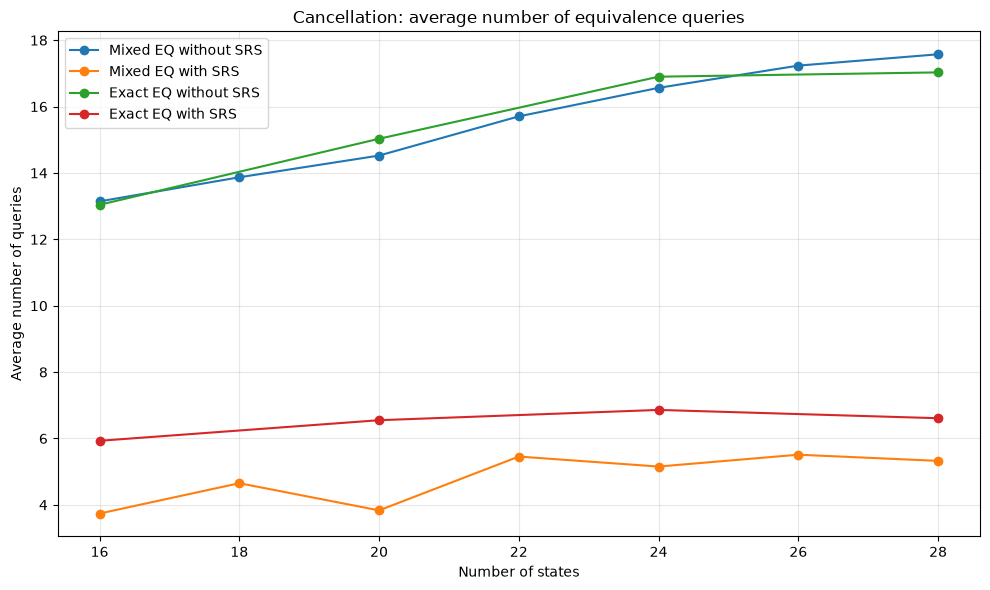

In [10]:
cancellationQueriesPlot = Plot(
    title="Cancellation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    cancellationQueriesPlot,
    cancellationMixedPath,
    cancellationExactPath,
    yColumn="equivalenceQueryCount",
)
cancellationQueriesPlot.draw()

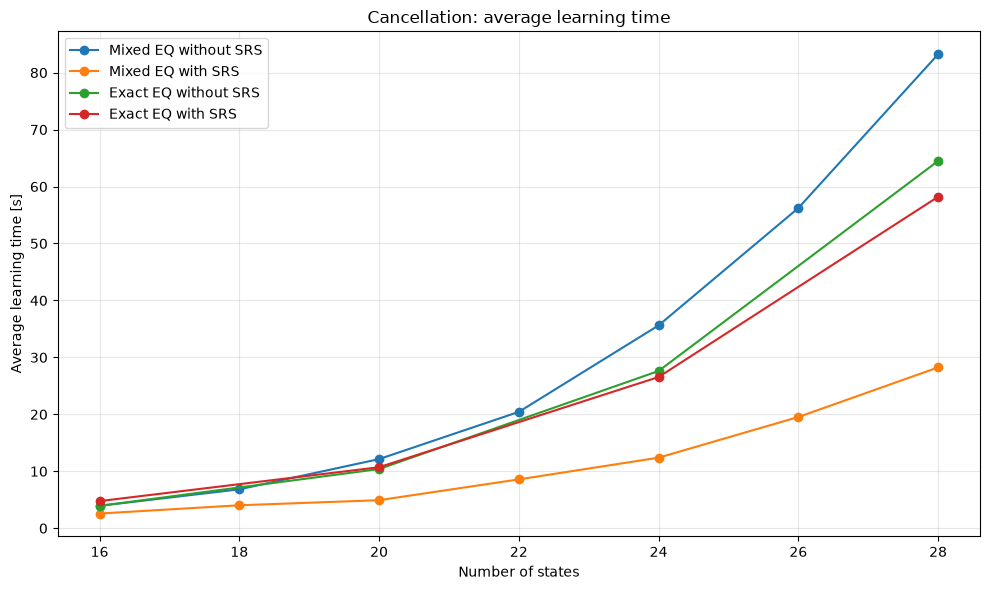

In [11]:
cancellationTimePlot = Plot(
    title="Cancellation: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    cancellationTimePlot,
    cancellationMixedPath,
    cancellationExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
cancellationTimePlot.draw()

In [12]:
print("Mixed EQ")
printMeanDecrease(cancellationMixedPath)
printMeanLearningTimeDecrease(cancellationMixedPath)

print("Exact EQ")
filters = exactFilters(cancellationMixedPath)
printMeanDecrease(cancellationExactPath, filters)
printMeanLearningTimeDecrease(cancellationExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 68.92%
Average procentage reduction in learning time 63.15%
Exact EQ
Average procentage reduction in equivalence queries 58.15%
Average procentage reduction in learning time 5.82%


## Commutativity

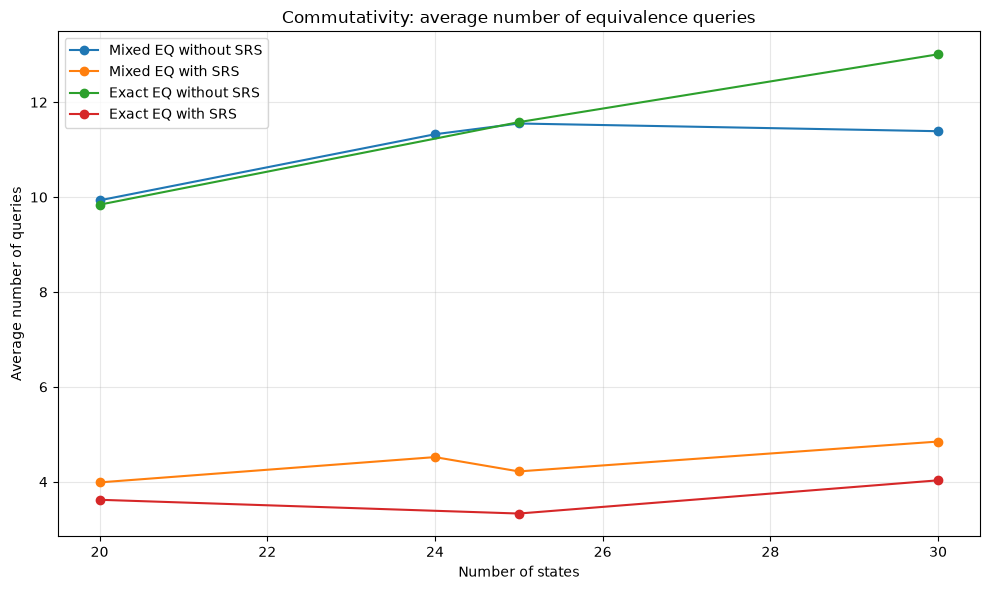

In [13]:
commutationQueriesPlot = Plot(
    title="Commutativity: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutationQueriesPlot,
    commutativeMixedPath,
    commutativeExactPath,
    yColumn="equivalenceQueryCount",
)
commutationQueriesPlot.draw()

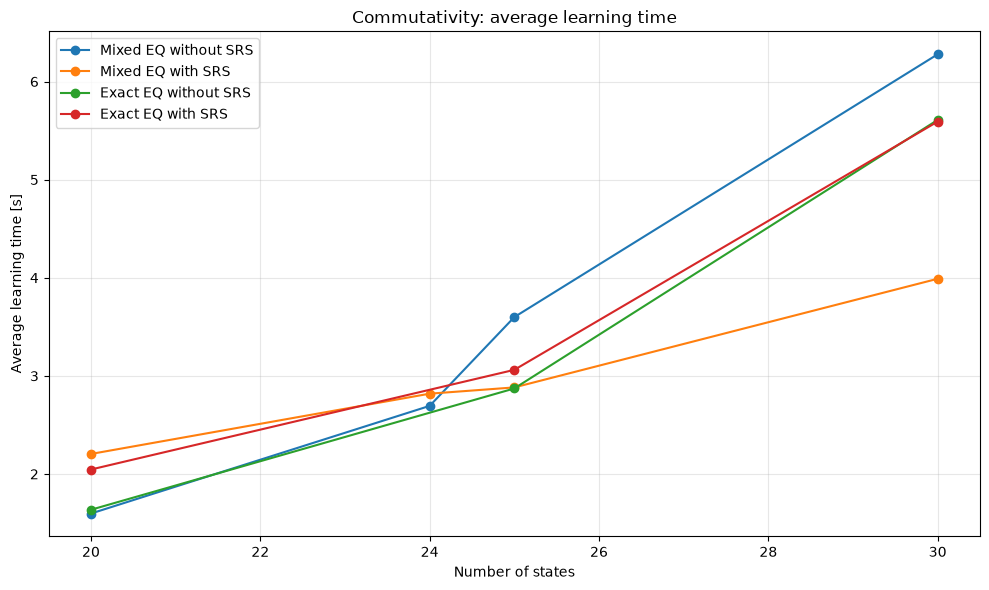

In [14]:
commutationTimePlot = Plot(
    title="Commutativity: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    commutationTimePlot,
    commutativeMixedPath,
    commutativeExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
commutationTimePlot.draw()

In [15]:
print("Mixed EQ")
printMeanDecrease(commutativeMixedPath)
printMeanLearningTimeDecrease(commutativeMixedPath)

print("Exact EQ")
filters = exactFilters(commutativeMixedPath)
printMeanDecrease(commutativeExactPath, filters)
printMeanLearningTimeDecrease(commutativeExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 60.31%
Average procentage reduction in learning time 15.78%
Exact EQ
Average procentage reduction in equivalence queries 68.11%
Average procentage reduction in learning time -5.76%


## Commutativity with increased alphabet

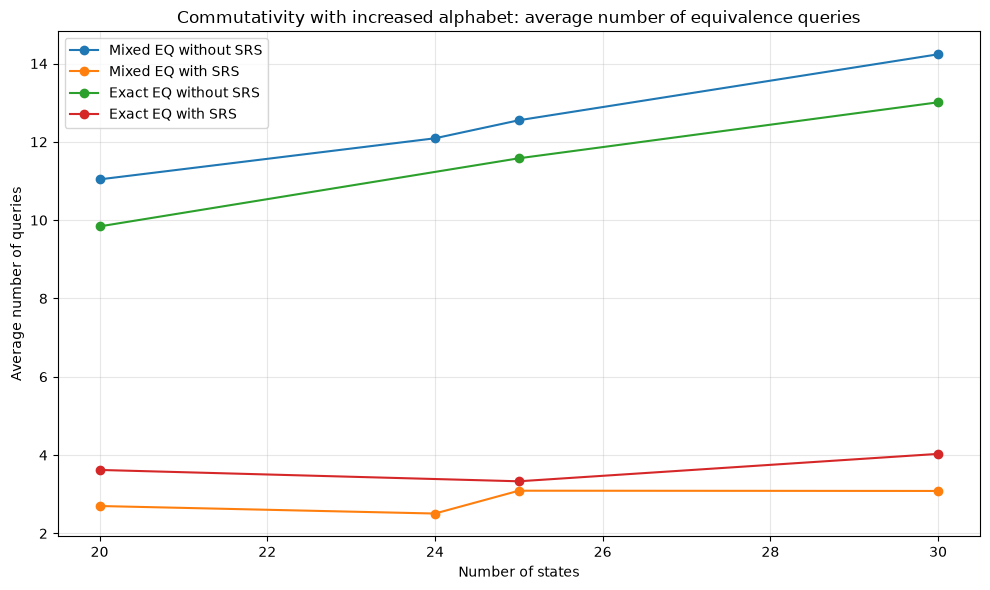

In [16]:
commutationIncreasedAlphabetQueriesPlot = Plot(
    title="Commutativity with increased alphabet: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutationIncreasedAlphabetQueriesPlot,
    commutativeMixedIncreasedAlphabetPath,
    commutativeExactPath,
    yColumn="equivalenceQueryCount",
)
commutationIncreasedAlphabetQueriesPlot.draw()

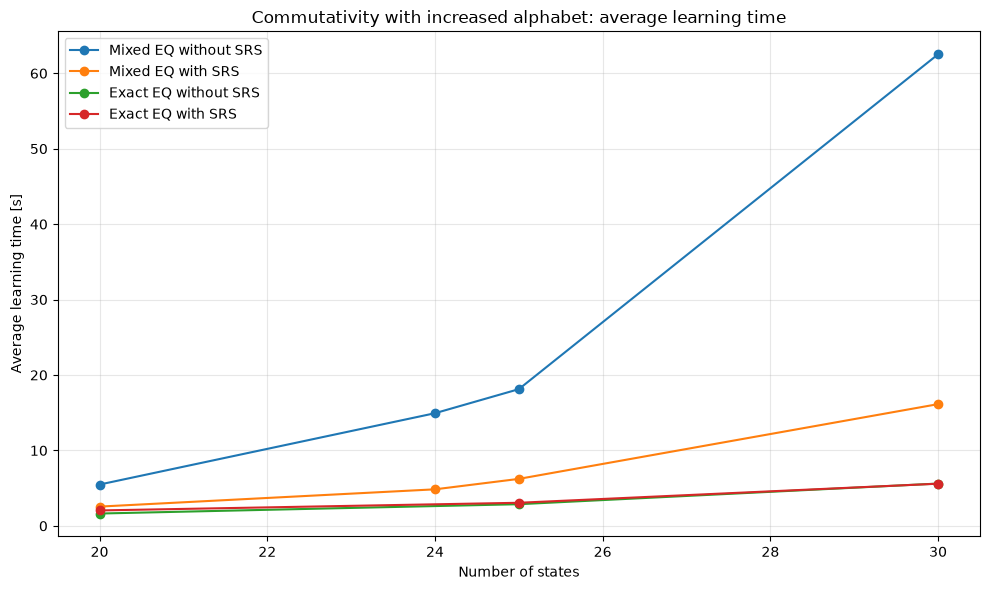

In [17]:
commutationIncreasedAlphabetTimePlot = Plot(
    title="Commutativity with increased alphabet: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    commutationIncreasedAlphabetTimePlot,
    commutativeMixedIncreasedAlphabetPath,
    commutativeExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
commutationIncreasedAlphabetTimePlot.draw()

In [18]:
print("Mixed EQ")
printMeanDecrease(commutativeMixedIncreasedAlphabetPath)
printMeanLearningTimeDecrease(commutativeMixedIncreasedAlphabetPath)

print("Exact EQ")
filters = exactFilters(commutativeMixedIncreasedAlphabetPath)
printMeanDecrease(commutativeExactPath, filters)
printMeanLearningTimeDecrease(commutativeExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 77.20%
Average procentage reduction in learning time 70.43%
Exact EQ
Average procentage reduction in equivalence queries 68.11%
Average procentage reduction in learning time -5.76%


## Idempotency

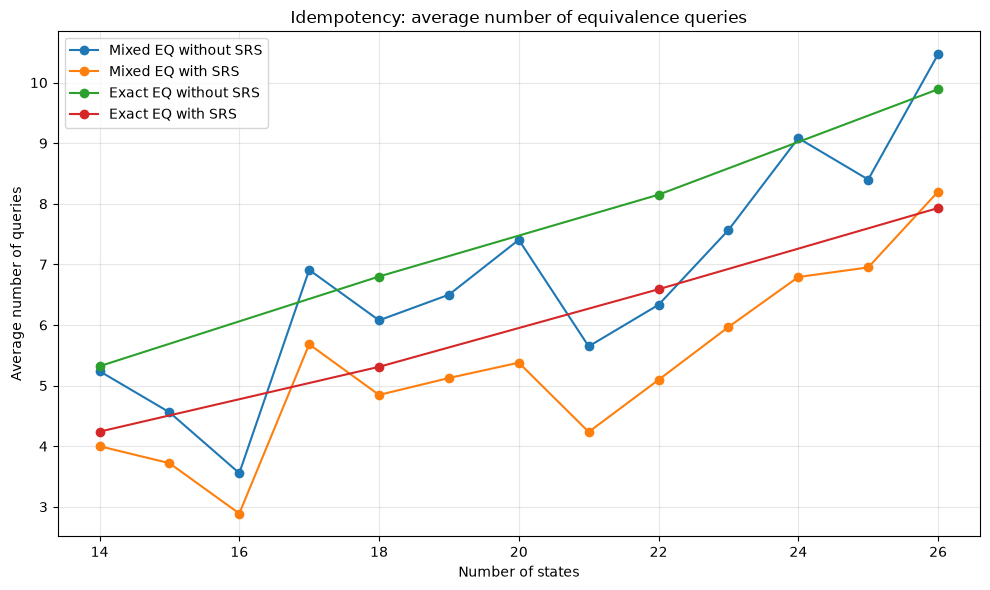

In [19]:
idempotencyQueriesPlot = Plot(
    title="Idempotency: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    idempotencyQueriesPlot,
    idempotencyMixedPath,
    idempotencyExactPath,
    yColumn="equivalenceQueryCount",
)
idempotencyQueriesPlot.draw()

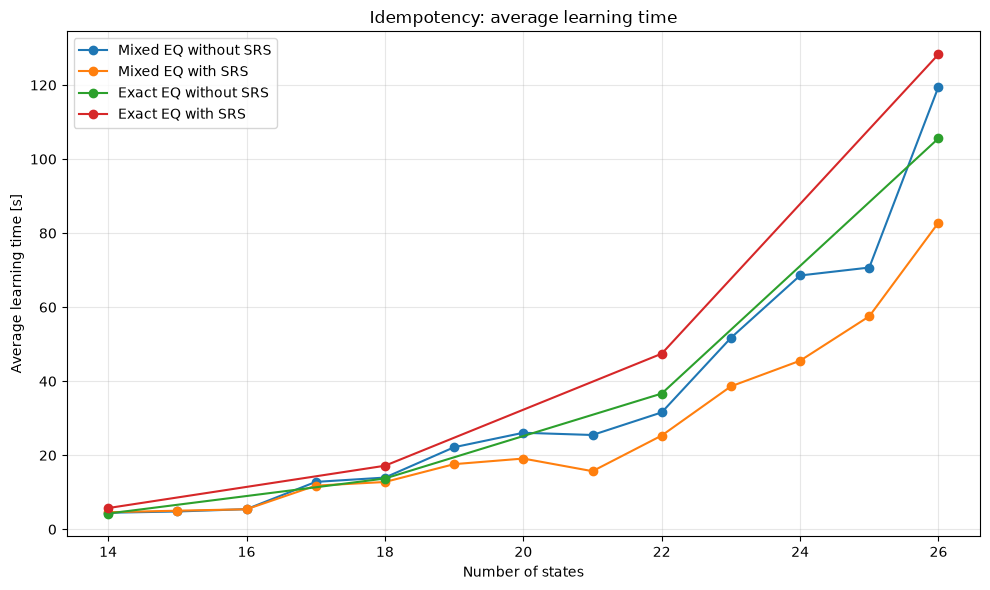

In [20]:
idempotencyTimePlot = Plot(
    title="Idempotency: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    idempotencyTimePlot,
    idempotencyMixedPath,
    idempotencyExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
idempotencyTimePlot.draw()

In [21]:
print("Mixed EQ")
printMeanDecrease(idempotencyMixedPath)
printMeanLearningTimeDecrease(idempotencyMixedPath)

print("Exact EQ")
filters = exactFilters(idempotencyMixedPath)
printMeanDecrease(idempotencyExactPath, filters)
printMeanLearningTimeDecrease(idempotencyExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 21.81%
Average procentage reduction in learning time 24.81%
Exact EQ
Average procentage reduction in equivalence queries 20.19%
Average procentage reduction in learning time -23.96%
